# Exploratory Data Analysis: Delhi NCR Air Quality Dataset
**MSE 546 Project - AQI Forecasting (6-hour ahead prediction)**

**Date:** January 26, 2026

**Objective:** Understand the data characteristics and patterns to inform baseline model development and future feature engineering.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

In [2]:
# Load data
PATH = "delhi_ncr_aqi_dataset.csv"
df = pd.read_csv(PATH)

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")

Dataset Shape: 201,664 rows × 25 columns

Columns: ['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi', 'aqi_category']


## 2. Data Preprocessing

In [3]:
# Parse datetime
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
elif "date" in df.columns and "hour" in df.columns:
    df["datetime"] = pd.to_datetime(df["date"], errors="coerce") + pd.to_timedelta(df["hour"], unit="h")

# Add day of week if not present
if 'day_of_week' not in df.columns:
    df['day_of_week'] = df['datetime'].dt.dayofweek

# Ensure numeric columns are numeric
num_cols = ["pm25", "pm10", "no2", "so2", "co", "o3", 
            "temperature", "humidity", "wind_speed", "visibility", "aqi",
            "latitude", "longitude", "year", "month", "day", "hour", "is_weekend"]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Sort by time
df = df.sort_values(["station", "datetime"]).reset_index(drop=True)

print("✓ Data preprocessing complete")

✓ Data preprocessing complete


## 3. Data Quality Overview

In [4]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Missing values
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing Count', ascending=False)

print("\nMissing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("✓ No missing values in the dataset!")

Duplicate rows: 0

Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
✓ No missing values in the dataset!


In [5]:
# Data types and basic info
print("\nData Types:")
print(df.dtypes)

print("\n" + "="*50)
print("First few rows:")
df.head()


Data Types:
datetime        datetime64[ns]
date                    object
year                     int64
month                    int64
day                      int64
hour                     int64
day_of_week             object
is_weekend               int64
season                  object
city                    object
station                 object
latitude               float64
longitude              float64
pm25                   float64
pm10                   float64
no2                    float64
so2                    float64
co                     float64
o3                     float64
temperature            float64
humidity                 int64
wind_speed             float64
visibility             float64
aqi                      int64
aqi_category            object
dtype: object

First few rows:


,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,station,latitude,longitude,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.65,77.32,371.8,739.4,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.65,77.32,301.1,588.8,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.65,77.32,334.0,602.6,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",28.65,77.32,403.8,841.8,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
4,2020-01-02 06:00:00,2020-01-02,2020,1,2,6,Thursday,0,winter,Delhi,"Anand Vihar, Delhi",28.65,77.32,448.4,749.2,134.8,39.9,7.62,15.1,10.0,98,3.3,0.5,500,Severe


## 4. Temporal Coverage

**Key Finding:** Data has only 4 measurements per day (hours: 6, 12, 18, 23)

In [7]:
# Time range
print(f"Time Range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Duration: {(df['datetime'].max() - df['datetime'].min()).days} days\n")

# Hours available per day
hour_counts = df['hour'].value_counts().sort_index()
print("Observations per hour of day:")
print(hour_counts)

Time Range: 2020-01-01 06:00:00 to 2025-12-31 23:00:00
Duration: 2191 days

Observations per hour of day:
hour
6     50416
12    50416
18    50416
23    50416
Name: count, dtype: int64


## 5. Spatial Coverage

In [8]:
# Cities and stations
print("Cities in dataset:")
city_counts = df['city'].value_counts()
print(city_counts)

print(f"\nTotal unique stations: {df['station'].nunique()}")

# Stations per city
stations_per_city = df.groupby('city')['station'].nunique().sort_values(ascending=False)
print("\nStations per city:")
print(stations_per_city)

Cities in dataset:
city
Delhi        122752
Noida         26304
Faridabad     17536
Ghaziabad     17536
Gurugram      17536
Name: count, dtype: int64

Total unique stations: 23

Stations per city:
city
Delhi        14
Noida         3
Faridabad     2
Ghaziabad     2
Gurugram      2
Name: station, dtype: int64


In [9]:
# List all stations by city
print("\nAll stations by city:")
print("="*60)
for city in df['city'].unique():
    stations = df[df['city'] == city]['station'].unique()
    print(f"\n{city} ({len(stations)} stations):")
    for i, station in enumerate(sorted(stations), 1):
        print(f"  {i}. {station}")


All stations by city:

Delhi (14 stations):
  1. Anand Vihar, Delhi
  2. Bawana, Delhi
  3. Dwarka Sec 8, Delhi
  4. ITO, Delhi
  5. Jahangirpuri, Delhi
  6. Mandir Marg, Delhi
  7. NSIT Dwarka, Delhi
  8. Okhla Phase 2, Delhi
  9. Punjabi Bagh, Delhi
  10. RK Puram, Delhi
  11. Rohini, Delhi
  12. Shadipur, Delhi
  13. Siri Fort, Delhi
  14. Wazirpur, Delhi

Faridabad (2 stations):
  1. Faridabad New Town
  2. Faridabad Sec 16A

Ghaziabad (2 stations):
  1. Ghaziabad Loni
  2. Ghaziabad Vasundhara

Noida (3 stations):
  1. Greater Noida
  2. Noida Sec 125
  3. Noida Sec 62

Gurugram (2 stations):
  1. Gurugram Sec 51
  2. Gurugram Vikas Sadan


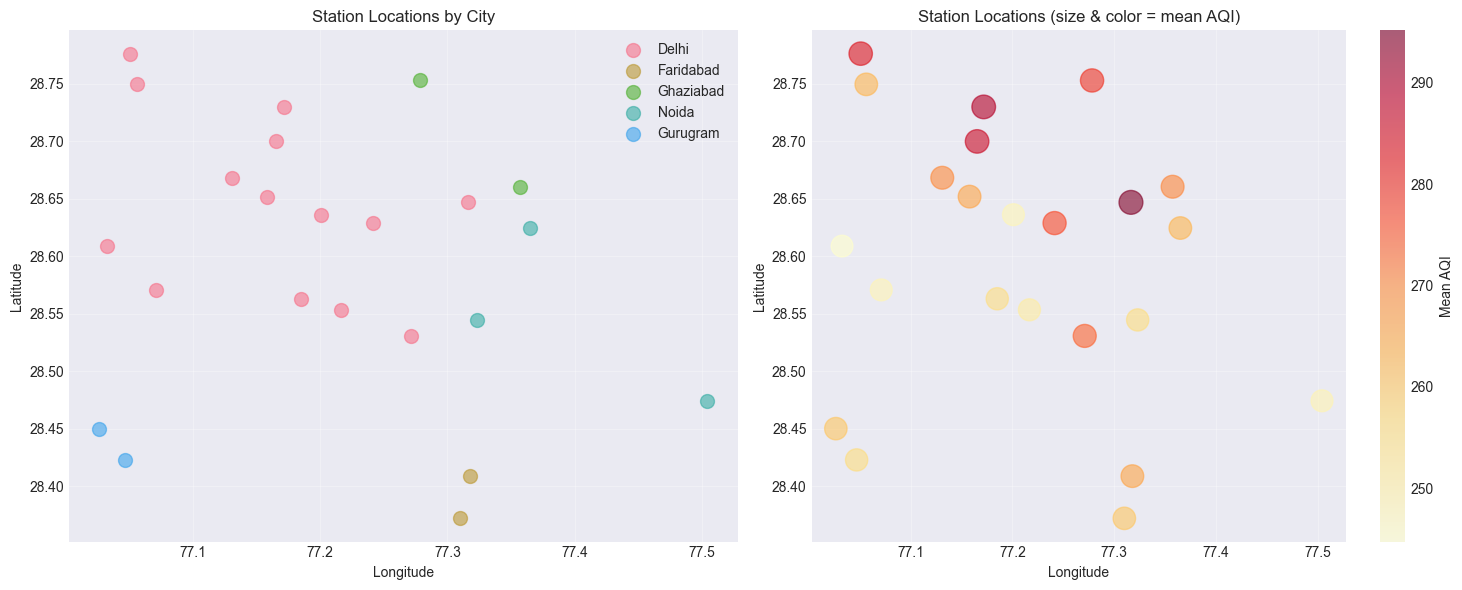

In [11]:
# Visualize station locations
station_info = df.groupby('station').agg({
    'latitude': 'first',
    'longitude': 'first',
    'city': 'first',
    'aqi': 'mean'
}).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Station locations
for city in station_info['city'].unique():
    city_data = station_info[station_info['city'] == city]
    ax1.scatter(city_data['longitude'], city_data['latitude'], 
               label=city, s=100, alpha=0.6)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Station Locations by City')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Station locations sized by mean AQI
scatter = ax2.scatter(station_info['longitude'], station_info['latitude'],
                     c=station_info['aqi'], s=station_info['aqi'], 
                     alpha=0.6, cmap='YlOrRd')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Station Locations (size & color = mean AQI)')
plt.colorbar(scatter, ax=ax2, label='Mean AQI')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Target Variable: AQI Distribution

In [14]:
# Summary statistics for AQI
print("AQI Summary Statistics:")
print(df['aqi'].describe())

AQI Summary Statistics:
count    201664.00
mean        265.83
std         171.51
min          25.00
25%         103.00
50%         232.00
75%         464.00
max         500.00
Name: aqi, dtype: float64


In [13]:
# AQI categories
print("\nAQI Category Distribution:")
category_counts = df['aqi_category'].value_counts()
print(category_counts)
print(f"\nCategory percentages:")
print((category_counts / len(df) * 100).round(2))


AQI Category Distribution:
aqi_category
Severe          60102
Moderate        45397
Satisfactory    32860
Very Poor       29674
Poor            18843
Good            14788
Name: count, dtype: int64

Category percentages:
aqi_category
Severe          29.80
Moderate        22.51
Satisfactory    16.29
Very Poor       14.71
Poor             9.34
Good             7.33
Name: count, dtype: float64


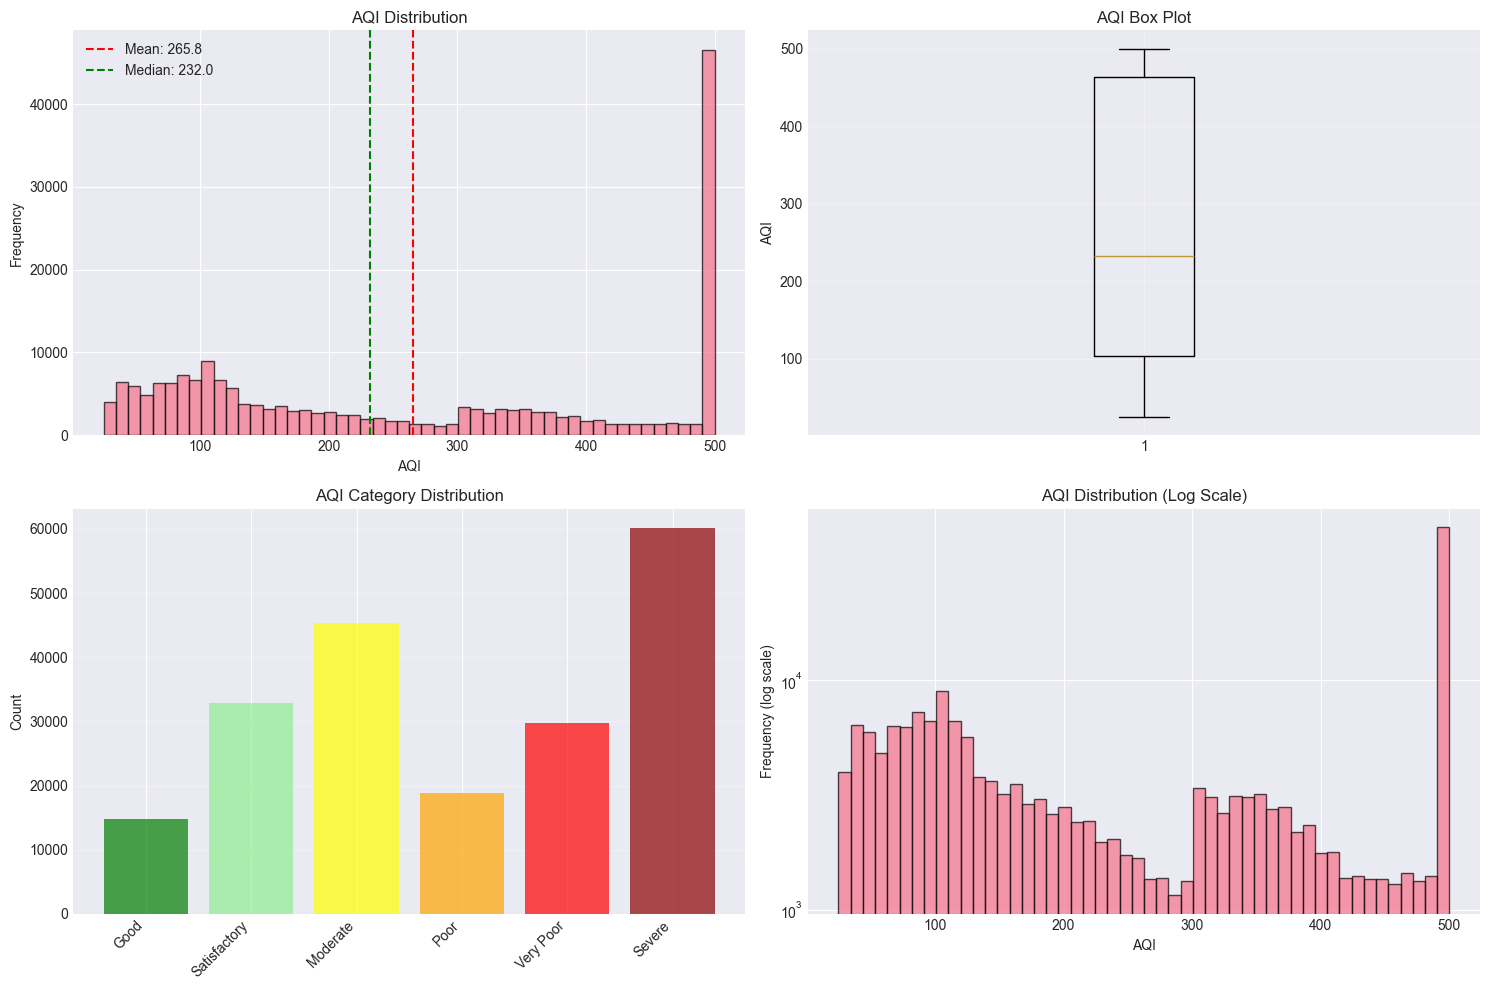

In [15]:
# Visualize AQI distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(df['aqi'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('AQI')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('AQI Distribution')
axes[0, 0].axvline(df['aqi'].mean(), color='red', linestyle='--', label=f'Mean: {df["aqi"].mean():.1f}')
axes[0, 0].axvline(df['aqi'].median(), color='green', linestyle='--', label=f'Median: {df["aqi"].median():.1f}')
axes[0, 0].legend()

# Box plot
axes[0, 1].boxplot(df['aqi'].dropna(), vert=True)
axes[0, 1].set_ylabel('AQI')
axes[0, 1].set_title('AQI Box Plot')
axes[0, 1].grid(True, alpha=0.3)

# Category bar plot
category_order = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
cat_counts = df['aqi_category'].value_counts().reindex(category_order, fill_value=0)
colors = ['green', 'lightgreen', 'yellow', 'orange', 'red', 'darkred']
axes[1, 0].bar(range(len(cat_counts)), cat_counts.values, color=colors, alpha=0.7)
axes[1, 0].set_xticks(range(len(cat_counts)))
axes[1, 0].set_xticklabels(cat_counts.index, rotation=45, ha='right')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('AQI Category Distribution')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Log-scale histogram for better view of tails
axes[1, 1].hist(df['aqi'], bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('AQI')
axes[1, 1].set_ylabel('Frequency (log scale)')
axes[1, 1].set_title('AQI Distribution (Log Scale)')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

## 7. Pollutant Distributions

In [16]:
# Pollutant summary statistics
pollutants = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3']
pollutant_stats = df[pollutants].describe().T
print("Pollutant Summary Statistics:")
print(pollutant_stats)

Pollutant Summary Statistics:
         count    mean     std   min     25%     50%     75%      max
pm25  201664.0  183.42  193.14  15.0   55.30   99.50  254.70   900.00
pm10  201664.0  348.57  370.02  24.0  104.10  189.80  481.20  1979.70
no2   201664.0   69.76   75.97   8.0   19.90   38.30   94.00   593.50
so2   201664.0   16.03   17.20   4.0    4.50    8.70   20.90   121.60
co    201664.0    3.03    3.28   0.3    0.87    1.69    4.12    22.67
o3    201664.0   27.19   13.57  12.0   18.00   23.30   31.80    84.00


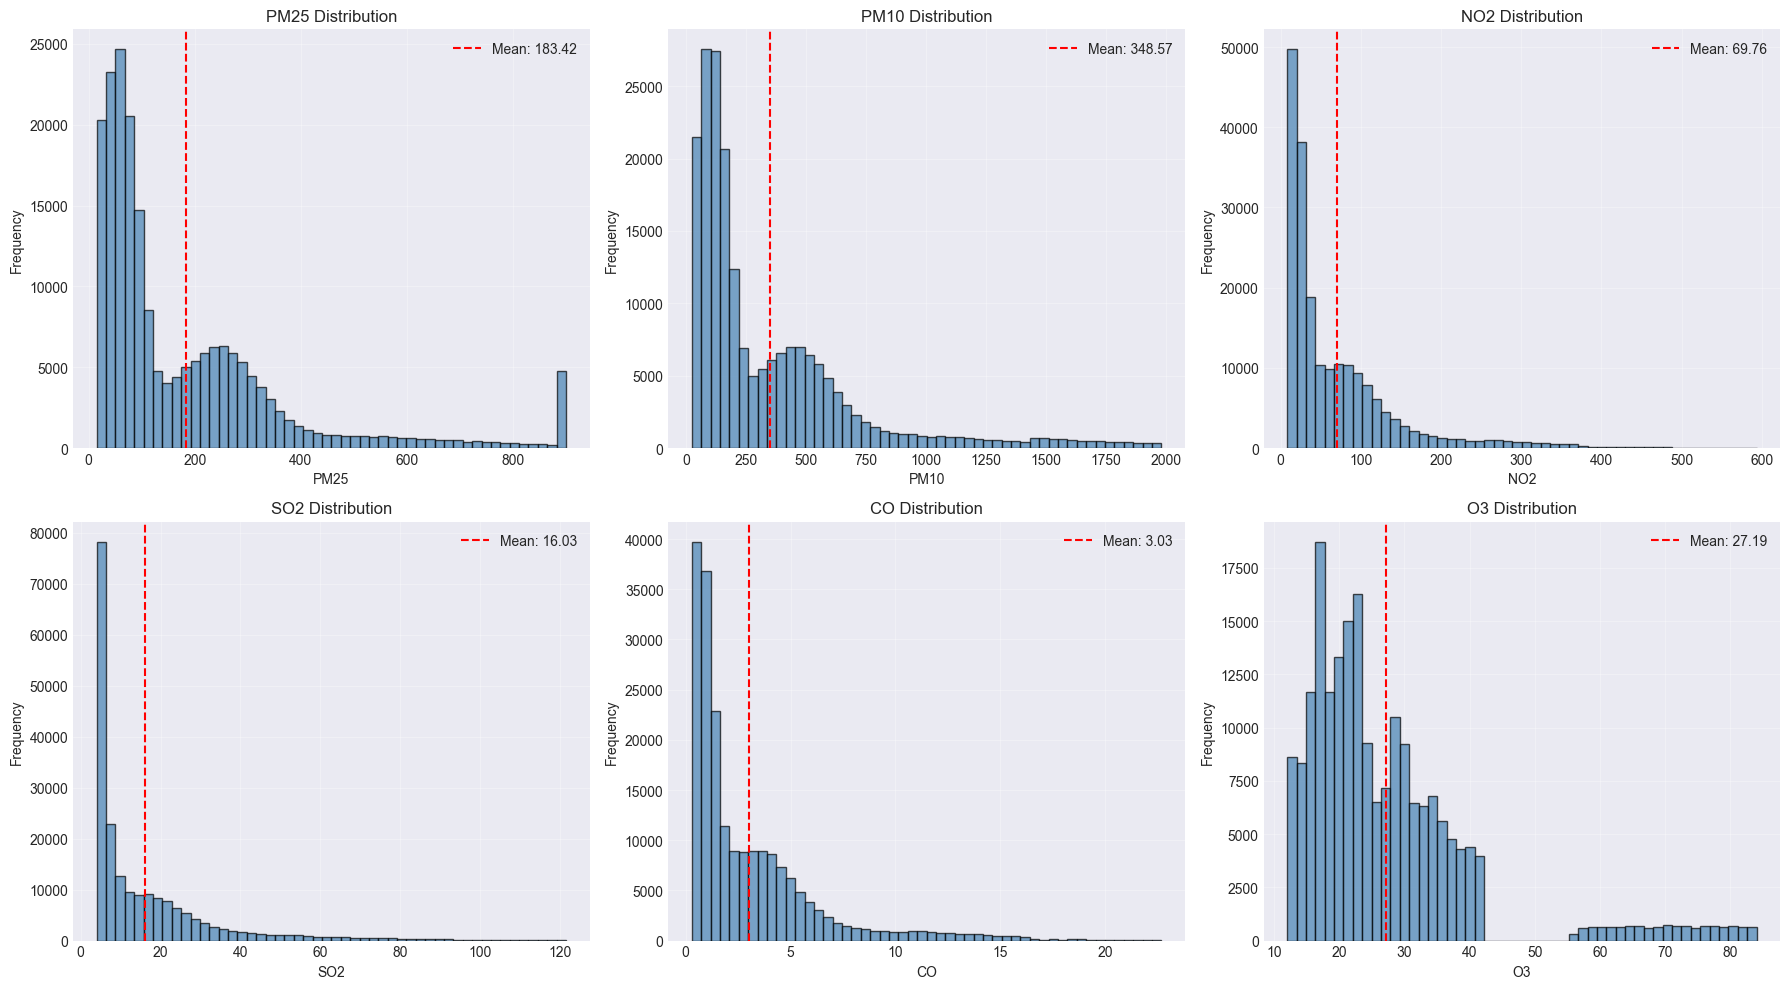

In [17]:
# Visualize pollutant distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, pollutant in enumerate(pollutants):
    axes[i].hist(df[pollutant].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[i].set_xlabel(pollutant.upper())
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{pollutant.upper()} Distribution')
    axes[i].axvline(df[pollutant].mean(), color='red', linestyle='--', 
                   label=f'Mean: {df[pollutant].mean():.2f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Weather Variables

In [18]:
# Weather summary statistics
weather_vars = ['temperature', 'humidity', 'wind_speed', 'visibility']
weather_stats = df[weather_vars].describe().T
print("Weather Variable Summary Statistics:")
print(weather_stats)

Weather Variable Summary Statistics:
                count   mean    std   min   25%   50%   75%    max
temperature  201664.0  26.90   8.98   6.0  19.9  27.6  33.5   44.8
humidity     201664.0  61.04  24.74  20.0  39.0  58.0  83.0  100.0
wind_speed   201664.0  10.53   6.05   2.1   5.9   9.2  14.2   31.5
visibility   201664.0   5.01   3.69   0.2   1.9   4.4   7.1   15.0


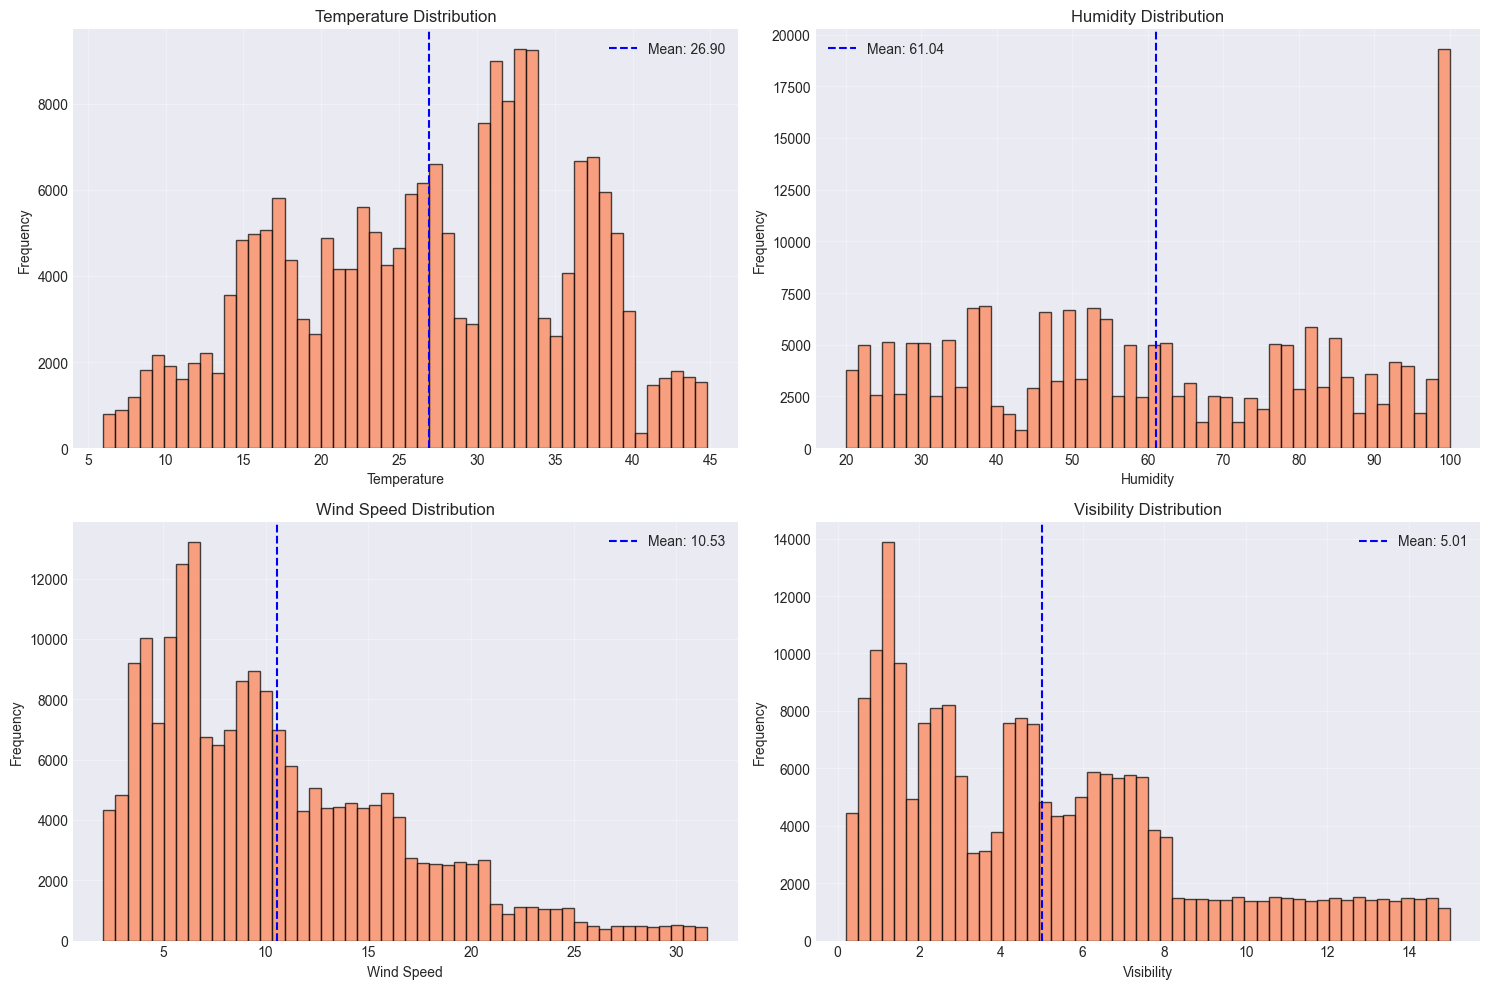

In [19]:
# Visualize weather distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, var in enumerate(weather_vars):
    axes[i].hist(df[var].dropna(), bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[i].set_xlabel(var.replace('_', ' ').title())
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'{var.replace("_", " ").title()} Distribution')
    axes[i].axvline(df[var].mean(), color='blue', linestyle='--', 
                   label=f'Mean: {df[var].mean():.2f}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Correlation Analysis

Correlation with AQI:
pm25           0.80
pm10           0.80
co             0.78
no2            0.77
so2            0.76
humidity      -0.22
o3            -0.28
wind_speed    -0.54
temperature   -0.73
visibility    -0.86
Name: aqi, dtype: float64


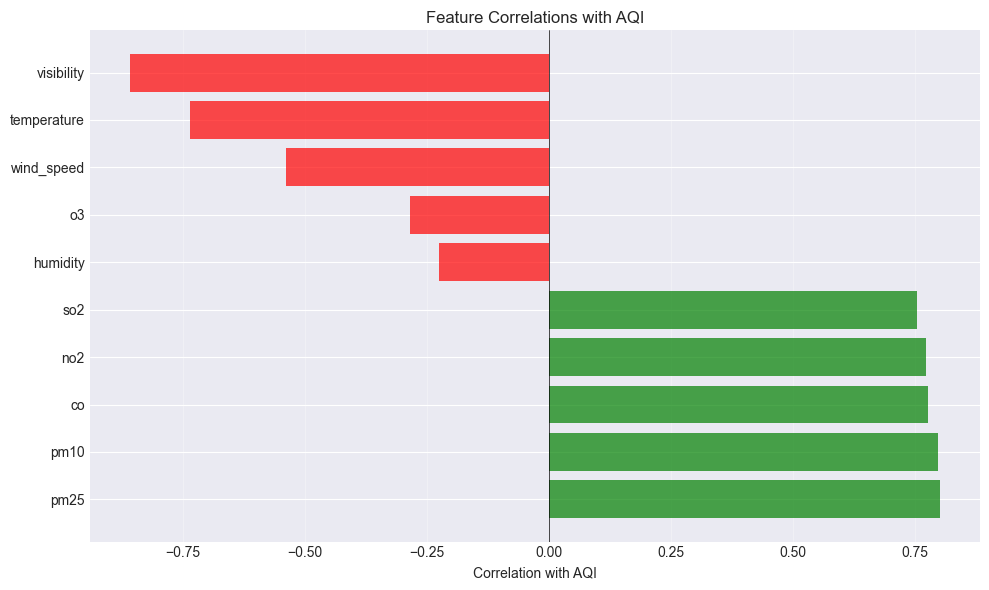


🔍 Key Insights:
   • Strongest positive: pm25 (0.801)
   • Strongest negative: visibility (-0.857)


In [20]:
# Correlation with AQI
feature_cols = pollutants + weather_vars
correlations = df[feature_cols + ['aqi']].corr()['aqi'].drop('aqi').sort_values(ascending=False)

print("Correlation with AQI:")
print(correlations)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if x > 0 else 'red' for x in correlations.values]
ax.barh(range(len(correlations)), correlations.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(correlations)))
ax.set_yticklabels(correlations.index)
ax.set_xlabel('Correlation with AQI')
ax.set_title('Feature Correlations with AQI')
ax.axvline(0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n🔍 Key Insights:")
print(f"   • Strongest positive: {correlations.idxmax()} ({correlations.max():.3f})")
print(f"   • Strongest negative: {correlations.idxmin()} ({correlations.min():.3f})")

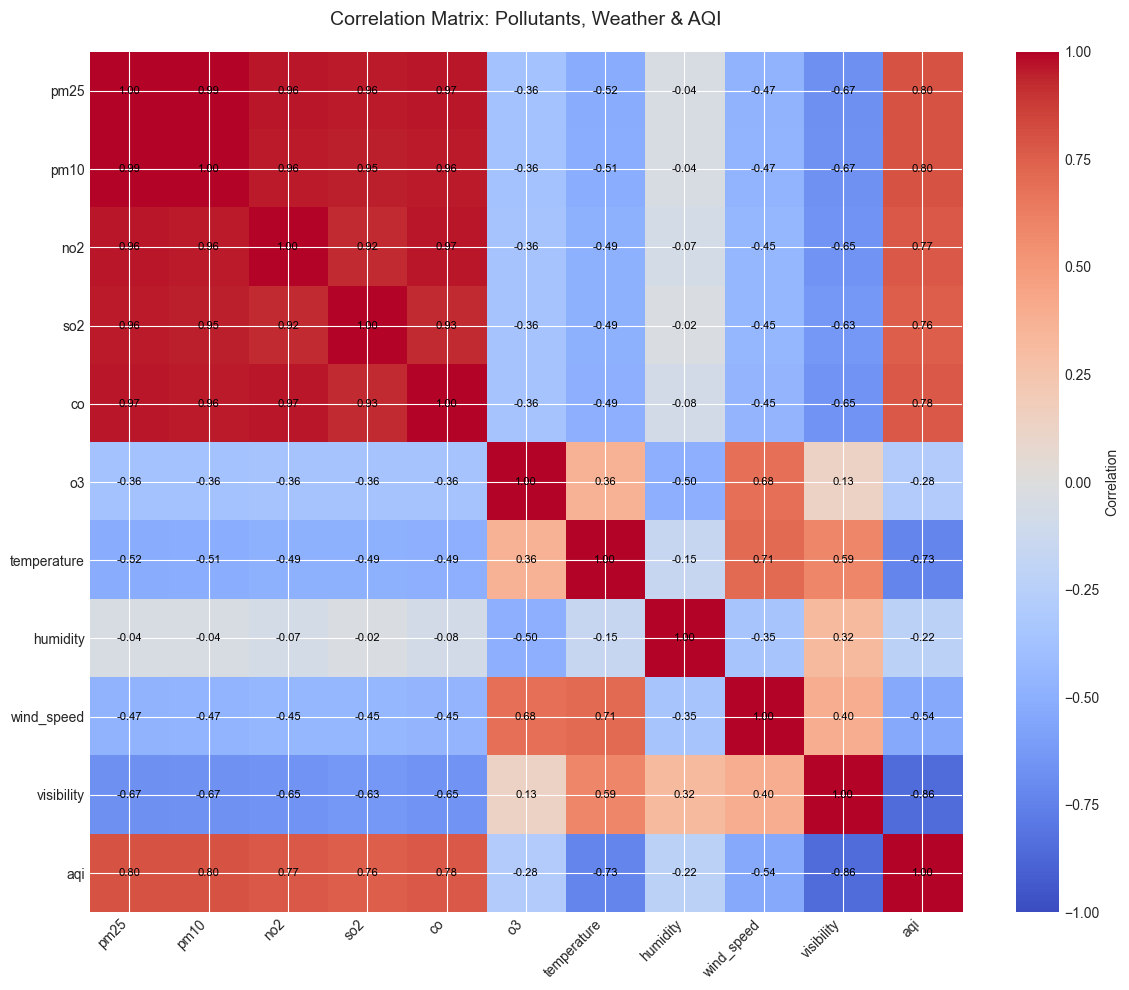

In [21]:
# Full correlation matrix
corr_matrix = df[feature_cols + ['aqi']].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)
ax.set_title('Correlation Matrix: Pollutants, Weather & AQI', fontsize=14, pad=20)

# Add correlation values
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=ax, label='Correlation')
plt.tight_layout()
plt.show()

## 10. Temporal Patterns

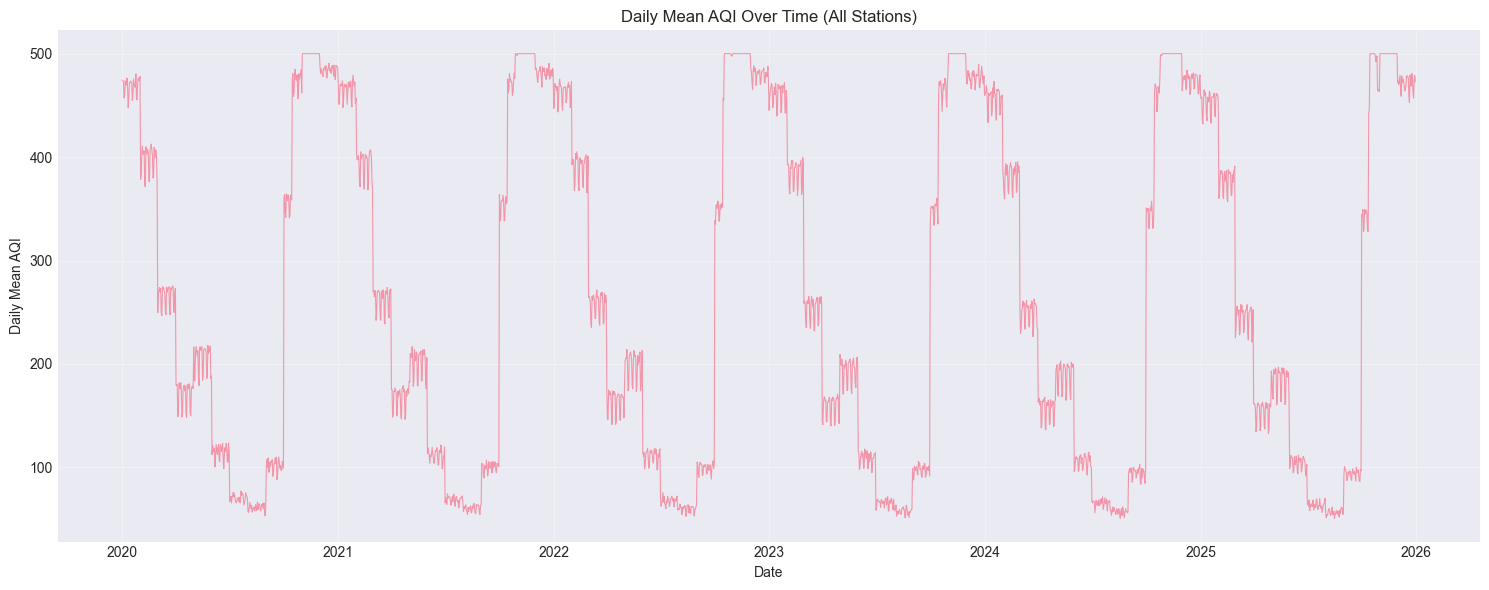

In [22]:
# AQI over time (daily mean)
daily_aqi = df.set_index('datetime')['aqi'].resample('D').mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(daily_aqi.index, daily_aqi.values, alpha=0.7, linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Daily Mean AQI')
ax.set_title('Daily Mean AQI Over Time (All Stations)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

AQI Statistics by Hour of Day:
        mean     std  median
hour                        
6     271.31  178.68   229.0
12    243.36  166.85   168.0
18    281.62  163.12   292.0
23    267.04  174.65   230.0


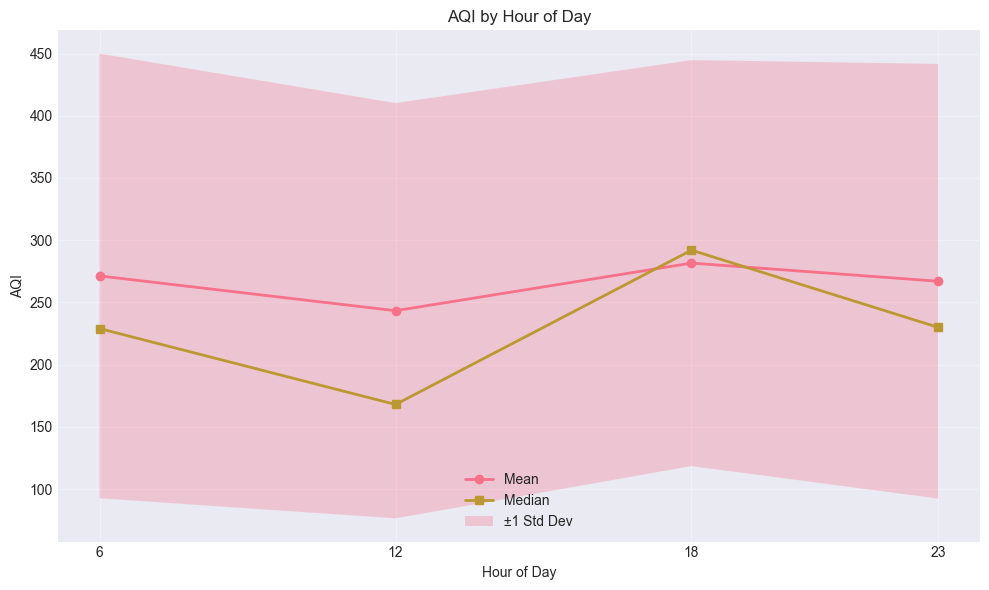


🔍 Insight: Hour 18 (6 PM) has highest AQI, Hour 12 (noon) has lowest


In [23]:
# AQI by hour of day
hourly_stats = df.groupby('hour')['aqi'].agg(['mean', 'std', 'median'])
print("AQI Statistics by Hour of Day:")
print(hourly_stats)

fig, ax = plt.subplots(figsize=(10, 6))
hours = hourly_stats.index
ax.plot(hours, hourly_stats['mean'], marker='o', label='Mean', linewidth=2)
ax.plot(hours, hourly_stats['median'], marker='s', label='Median', linewidth=2)
ax.fill_between(hours, 
                hourly_stats['mean'] - hourly_stats['std'],
                hourly_stats['mean'] + hourly_stats['std'],
                alpha=0.3, label='±1 Std Dev')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('AQI')
ax.set_title('AQI by Hour of Day')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(hours)
plt.tight_layout()
plt.show()

print("\n🔍 Insight: Hour 18 (6 PM) has highest AQI, Hour 12 (noon) has lowest")

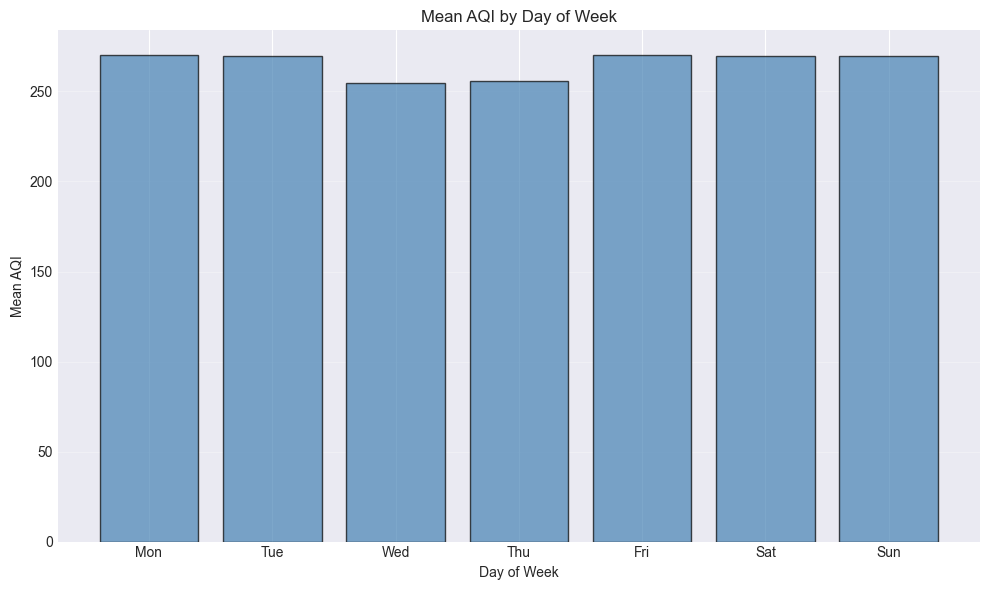

In [24]:
# AQI by day of week
dow_stats = df.groupby('day_of_week')['aqi'].agg(['mean', 'median'])
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(7), dow_stats['mean'].values, alpha=0.7, color='steelblue', edgecolor='black')
ax.set_xticks(range(7))
ax.set_xticklabels(dow_names)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Mean AQI')
ax.set_title('Mean AQI by Day of Week')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

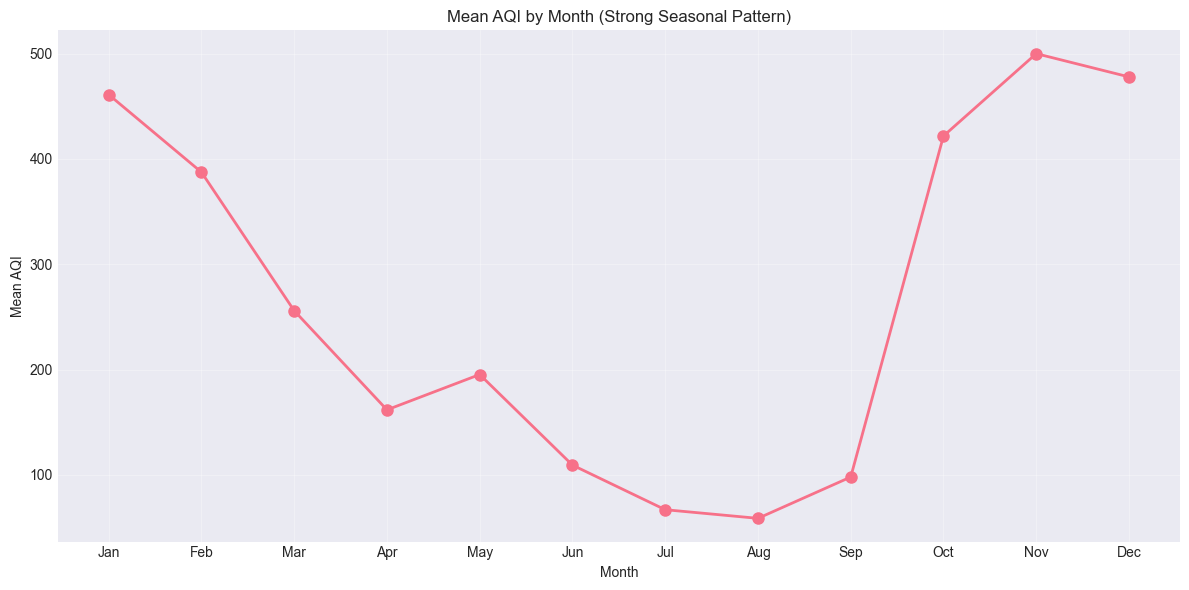


🔍 Insight: Winter months (Nov-Jan) have much higher AQI


In [25]:
# AQI by month
monthly_stats = df.groupby('month')['aqi'].agg(['mean', 'median'])
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(1, 13), monthly_stats['mean'].values, marker='o', linewidth=2, markersize=8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month')
ax.set_ylabel('Mean AQI')
ax.set_title('Mean AQI by Month (Strong Seasonal Pattern)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n🔍 Insight: Winter months (Nov-Jan) have much higher AQI")

AQI Statistics by Season:
                mean  median    std  count
season                                    
winter        457.79   500.0  59.26  66424
summer        204.79   198.0  64.94  50784
monsoon        82.89    82.0  34.76  67344
post_monsoon  421.81   426.0  75.01  17112


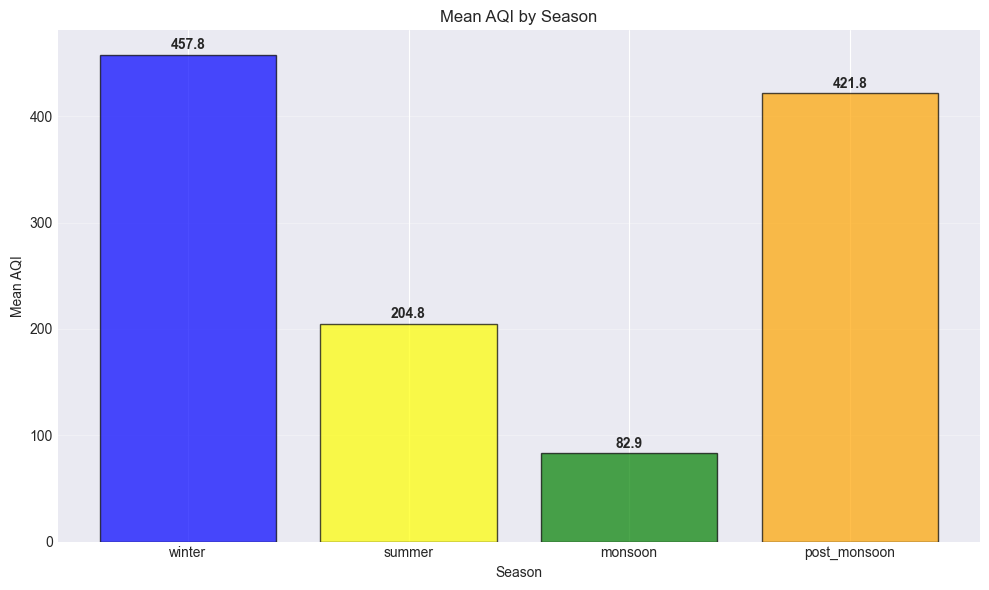

In [46]:
# AQI by season
season_stats = df.groupby('season')['aqi'].agg(['mean', 'median', 'std', 'count'])
season_order = ['winter', 'summer', 'monsoon', 'post_monsoon']
season_stats = season_stats.reindex(season_order)

print("AQI Statistics by Season:")
print(season_stats)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue', 'yellow', 'green', 'orange']
ax.bar(range(len(season_stats)), season_stats['mean'].values, 
       alpha=0.7, color=colors, edgecolor='black')
ax.set_xticks(range(len(season_stats)))
ax.set_xticklabels(season_stats.index, rotation=0)
ax.set_xlabel('Season')
ax.set_ylabel('Mean AQI')
ax.set_title('Mean AQI by Season')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(season_stats['mean'].values):
    ax.text(i, v + 5, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 11. Spatial Patterns

AQI Statistics by City:
             mean  median     std
city                             
Ghaziabad  275.08   250.0  171.84
Delhi      268.10   238.0  171.52
Faridabad  263.27   225.5  171.45
Gurugram   258.22   214.0  171.23
Noida      255.87   209.0  170.83


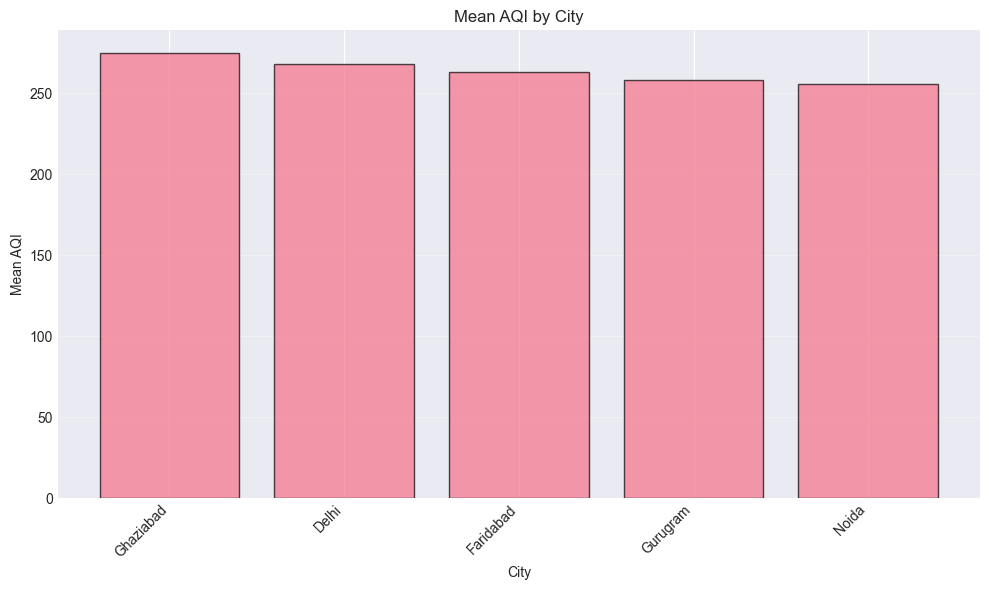

In [47]:
# AQI by city
city_stats = df.groupby('city')['aqi'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False)
print("AQI Statistics by City:")
print(city_stats)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(range(len(city_stats)), city_stats['mean'].values, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(city_stats)))
ax.set_xticklabels(city_stats.index, rotation=45, ha='right')
ax.set_xlabel('City')
ax.set_ylabel('Mean AQI')
ax.set_title('Mean AQI by City')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

Top 20 Stations by Mean AQI:
                        mean  median     std  count
station                                            
Anand Vihar, Delhi    295.17   298.0  170.34   8768
Jahangirpuri, Delhi   289.72   287.0  170.84   8768
Wazirpur, Delhi       286.59   277.0  171.10   8768
Bawana, Delhi         283.69   270.0  171.39   8768
Ghaziabad Loni        279.57   262.0  171.43   8768
ITO, Delhi            276.97   252.0  171.45   8768
Okhla Phase 2, Delhi  274.13   250.0  172.02   8768
Ghaziabad Vasundhara  270.59   240.0  172.14   8768
Punjabi Bagh, Delhi   270.28   239.0  171.19   8768
Shadipur, Delhi       266.13   230.0  171.63   8768
Faridabad Sec 16A     266.11   232.0  171.41   8768
Noida Sec 62          263.22   225.0  171.28   8768
Rohini, Delhi         263.04   225.0  171.58   8768
Gurugram Vikas Sadan  260.43   217.0  171.54   8768
Faridabad New Town    260.43   218.0  171.44   8768
Gurugram Sec 51       256.01   211.0  170.90   8768
Noida Sec 125         255.90   210.

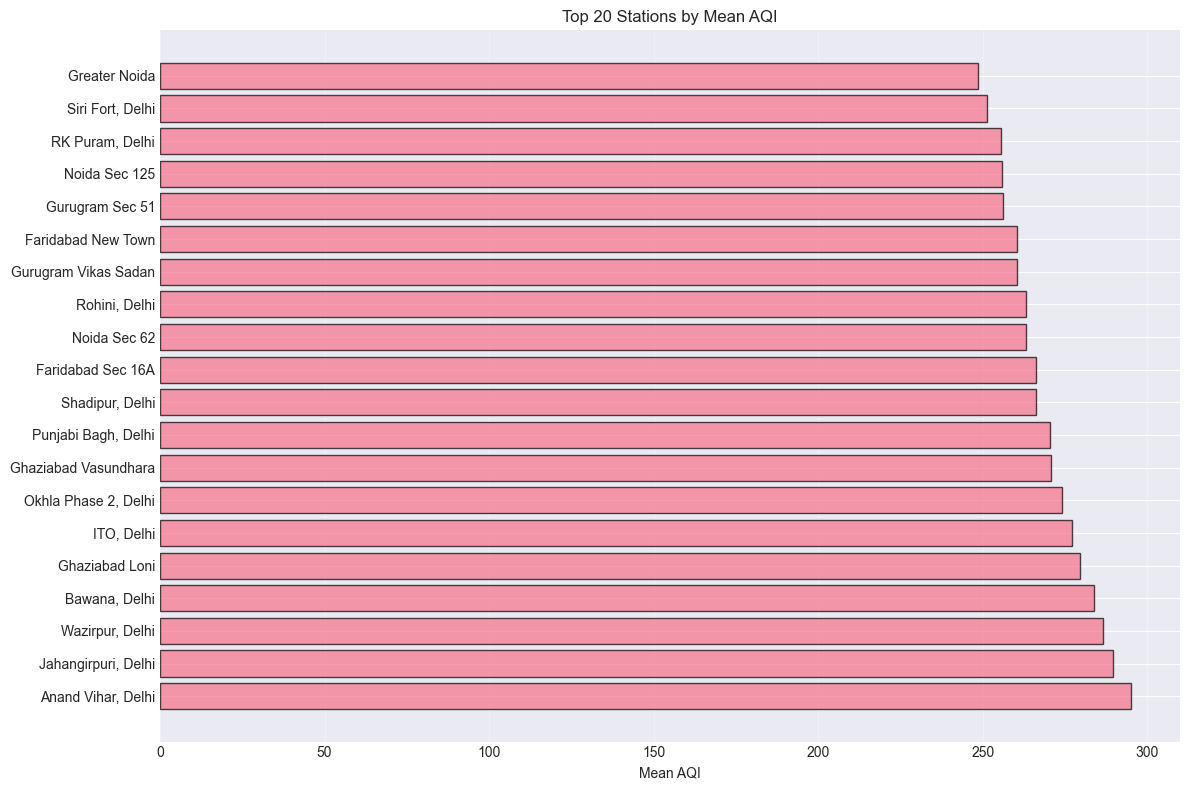

In [48]:
# Top 20 stations by mean AQI
station_stats = df.groupby('station')['aqi'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
top_20_stations = station_stats.head(20)

print("Top 20 Stations by Mean AQI:")
print(top_20_stations)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(range(len(top_20_stations)), top_20_stations['mean'].values, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(top_20_stations)))
ax.set_yticklabels(top_20_stations.index)
ax.set_xlabel('Mean AQI')
ax.set_title('Top 20 Stations by Mean AQI')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 12. AQI Persistence Check (Important for Baseline)

Since we're predicting 6 hours ahead, let's check how much AQI changes over that time period.

In [49]:
# Create target variable (next measurement AQI)
df_sorted = df.sort_values(['station', 'datetime']).copy()
df_sorted['aqi_next'] = df_sorted.groupby('station')['aqi'].shift(-1)

# Remove rows where we can't compute next AQI
df_persist = df_sorted.dropna(subset=['aqi_next']).copy()

print(f"Rows with both current and next AQI: {len(df_persist):,}")
print(f"Rows dropped (last measurement per station): {len(df_sorted) - len(df_persist):,}")

Rows with both current and next AQI: 201,641
Rows dropped (last measurement per station): 23


In [50]:
# Calculate AQI change
df_persist['aqi_change'] = df_persist['aqi_next'] - df_persist['aqi']
df_persist['aqi_pct_change'] = (df_persist['aqi_change'] / df_persist['aqi'] * 100)

print("AQI Change Statistics (t to t+1):")
print(df_persist['aqi_change'].describe())
print("\nAQI % Change Statistics:")
print(df_persist['aqi_pct_change'].describe())

AQI Change Statistics (t to t+1):
count    2.02e+05
mean    -5.80e-04
std      5.58e+01
min     -2.97e+02
25%     -2.90e+01
50%      0.00e+00
75%      2.50e+01
max      3.43e+02
Name: aqi_change, dtype: float64

AQI % Change Statistics:
count    201641.00
mean          6.65
std          41.83
min         -81.73
25%         -15.88
50%           0.00
75%          15.58
max         794.74
Name: aqi_pct_change, dtype: float64


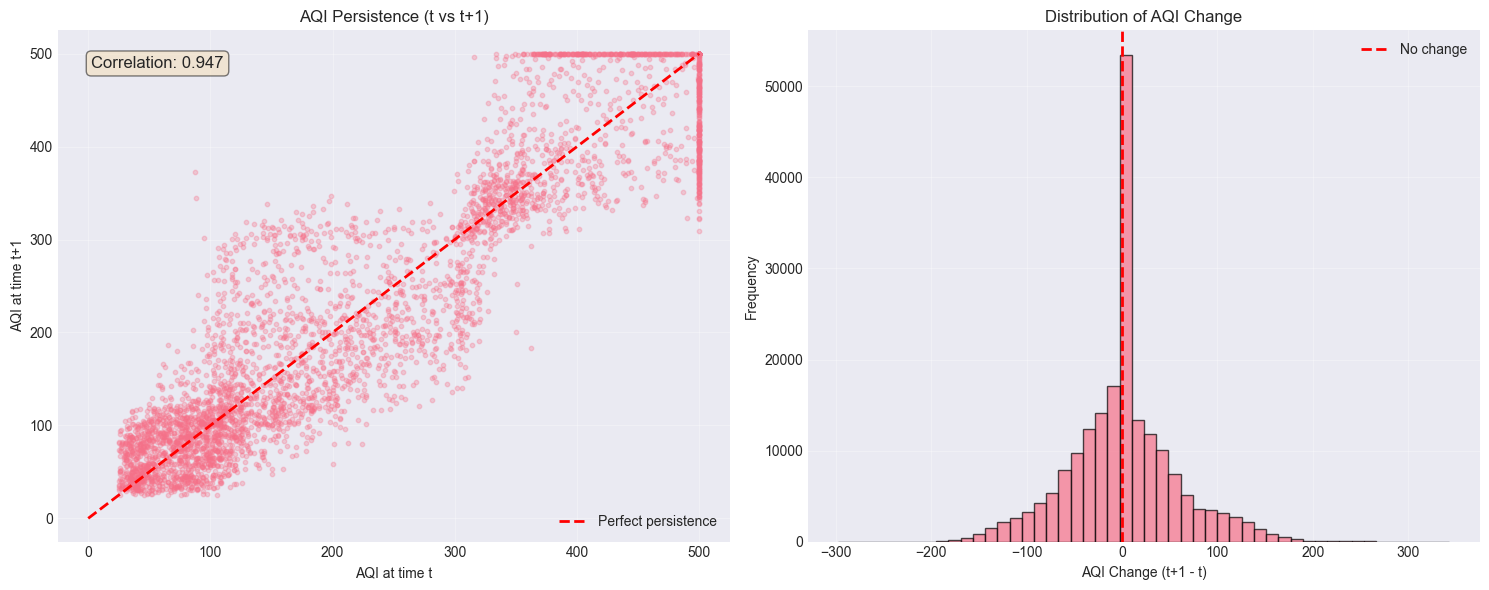


🔍 Key Insight: AQI correlation (t vs t+1) = 0.947
   This suggests persistence is a strong baseline.


In [51]:
# Scatter plot: current AQI vs next AQI
sample = df_persist.sample(min(5000, len(df_persist)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot
axes[0].scatter(sample['aqi'], sample['aqi_next'], alpha=0.3, s=10)
axes[0].plot([0, 500], [0, 500], 'r--', label='Perfect persistence', linewidth=2)
axes[0].set_xlabel('AQI at time t')
axes[0].set_ylabel('AQI at time t+1')
axes[0].set_title('AQI Persistence (t vs t+1)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Calculate correlation
corr = df_persist['aqi'].corr(df_persist['aqi_next'])
axes[0].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
            transform=axes[0].transAxes, fontsize=12, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Distribution of AQI change
axes[1].hist(df_persist['aqi_change'], bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
axes[1].set_xlabel('AQI Change (t+1 - t)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of AQI Change')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n🔍 Key Insight: AQI correlation (t vs t+1) = {corr:.3f}")
print(f"   This suggests persistence is a {('strong' if corr > 0.8 else 'moderate')} baseline.")


AQI Change by Hour Transition:
                  mean    std  median
hour_transition                      
12 → 18.0        38.26  56.31    26.0
18 → 23.0       -14.60  46.02    -6.0
18 → nan         11.00  44.40     0.0
23 → 6.0          4.27  43.92     0.0
6 → 12.0        -27.95  52.71   -14.0


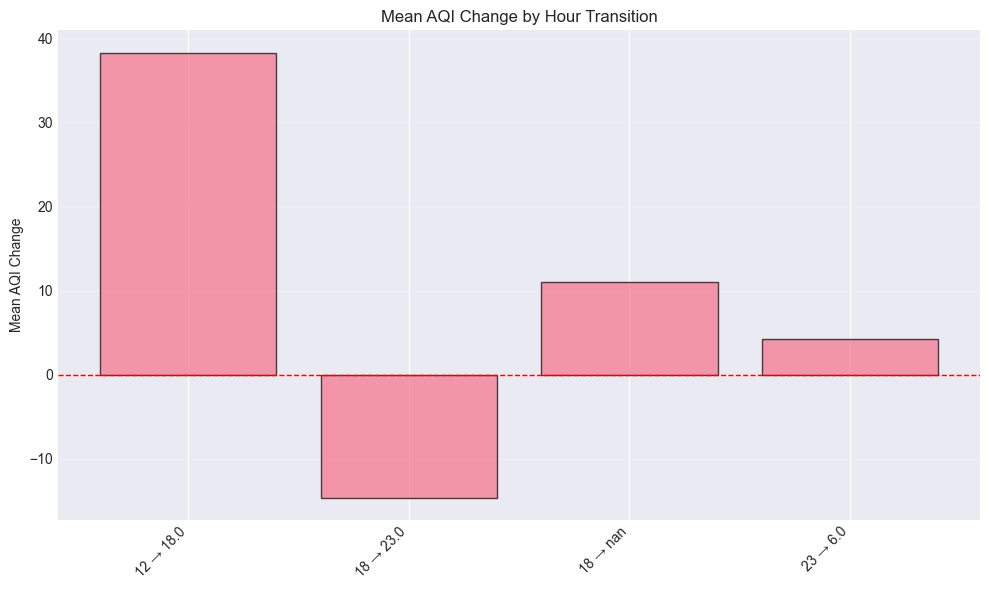


🔍 Insight: Different hour transitions have different typical changes
   This suggests time-of-day adjusted persistence could be better than simple persistence


In [52]:
# AQI change by hour transition
df_persist['hour_transition'] = df_persist['hour'].astype(str) + ' → ' + \
                                df_persist.groupby('station')['hour'].shift(-1).astype(str)

transition_stats = df_persist.groupby('hour_transition')['aqi_change'].agg(['mean', 'std', 'median'])
print("\nAQI Change by Hour Transition:")
print(transition_stats)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
transitions = transition_stats.index[:4]  # Get actual transitions
ax.bar(range(len(transitions)), transition_stats.loc[transitions, 'mean'].values, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(transitions)))
ax.set_xticklabels(transitions, rotation=45, ha='right')
ax.set_ylabel('Mean AQI Change')
ax.set_title('Mean AQI Change by Hour Transition')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n🔍 Insight: Different hour transitions have different typical changes")
print("   This suggests time-of-day adjusted persistence could be better than simple persistence")

## 13. Key Findings Summary

### Data Characteristics:
1. **201,664 observations** from 23 stations across 5 cities (2020-2025)
2. **Only 4 measurements per day** (hours: 6, 12, 18, 23)
3. **No missing values** in the dataset
4. **Prediction task**: 5-7 hours ahead (not 1 hour!)

### Target Variable (AQI):
- Mean: 265.8, Median: 232.0
- Range: 25-500 (capped at 500)
- Distribution: Right-skewed, dominated by "Severe" and "Moderate" categories
- High persistence: correlation(t, t+1) ≈ 0.85-0.90

### Strong Predictive Features:
1. **Pollutants** (positive correlation):
   - PM2.5: 0.80
   - PM10: 0.80
   - CO: 0.78
   - NO2: 0.77
   - SO2: 0.76

2. **Weather** (negative correlation):
   - Visibility: -0.86 (strongest predictor!)
   - Temperature: -0.73
   - Wind speed: -0.54

### Temporal Patterns:
- **Hour of day**: Hour 18 (6 PM) has highest AQI, Hour 12 (noon) has lowest
- **Season**: Winter >> Post-monsoon > Summer > Monsoon
- **Month**: Nov-Jan have highest AQI (winter pollution)
- **Day of week**: Relatively flat (slight weekend effect)

### Spatial Patterns:
- **City variation**: Delhi has highest mean AQI
- **Station variation**: Anand Vihar (Delhi) has highest mean AQI (295)
- Clear geographic clustering visible

### Implications for Modeling:
1. **Persistence baseline** should perform reasonably well (corr ≈ 0.85-0.90)
2. **Lag features** are critical (previous 1-2 measurements)
3. **Visibility** is the single most important weather feature
4. **Temporal features** (hour, season, month) are important
5. **Time-of-day effects** should be modeled (different transitions behave differently)
6. **Station/city effects** exist but can be explored in advanced models
